In [19]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [20]:
# -------------------------------------------------
# Load data
# -------------------------------------------------
digits = load_digits()
X = digits.data
y = digits.target

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (1797, 64)
y shape: (1797,)


In [21]:
# -------------------------------------------------
# Standardize
# -------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [22]:
# -------------------------------------------------
# PCA to 2D
# -------------------------------------------------
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

print("\nPCA explained variance ratio:", pca_2.explained_variance_ratio_)
print("Total variance retained by 2 PCs:", pca_2.explained_variance_ratio_.sum())



PCA explained variance ratio: [0.12033916 0.09561054]
Total variance retained by 2 PCs: 0.2159497050083278


In [23]:
# -------------------------------------------------
# LDA to 2D
#    Digits has 10 classes, so max LDA components = 9
#    2D is fine for visualization
# -------------------------------------------------
lda_2 = LinearDiscriminantAnalysis(n_components=2)
X_lda_2 = lda_2.fit_transform(X_scaled, y)

In [24]:
# -------------------------------------------------
# t-SNE to 2D
# -------------------------------------------------
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
)
X_tsne_2 = tsne.fit_transform(X_scaled)


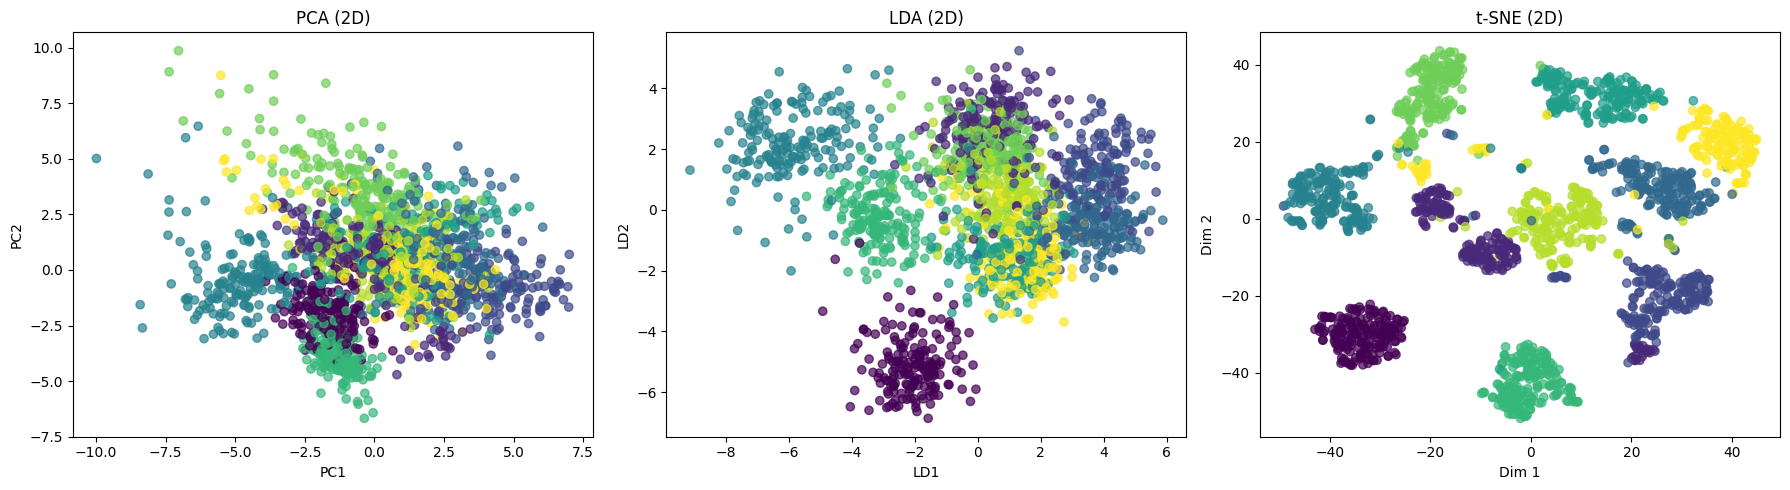

In [25]:
# -------------------------------------------------
# Visual comparison: PCA vs LDA vs t-SNE
# -------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=y, alpha=0.7)
axes[0].set_title("PCA (2D)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(X_lda_2[:, 0], X_lda_2[:, 1], c=y, alpha=0.7)
axes[1].set_title("LDA (2D)")
axes[1].set_xlabel("LD1")
axes[1].set_ylabel("LD2")

axes[2].scatter(X_tsne_2[:, 0], X_tsne_2[:, 1], c=y, alpha=0.7)
axes[2].set_title("t-SNE (2D)")
axes[2].set_xlabel("Dim 1")
axes[2].set_ylabel("Dim 2")

plt.tight_layout()
plt.show()


In [27]:
# -------------------------------------------------
# Neighbor overlap with original high-D space
# -------------------------------------------------
k = 10

nn_high = NearestNeighbors(n_neighbors=k + 1)
nn_high.fit(X_scaled)
neighbors_high = nn_high.kneighbors(X_scaled, return_distance=False)[:, 1:]

nn_pca = NearestNeighbors(n_neighbors=k + 1)
nn_pca.fit(X_pca_2)
neighbors_pca = nn_pca.kneighbors(X_pca_2, return_distance=False)[:, 1:]

nn_lda = NearestNeighbors(n_neighbors=k + 1)
nn_lda.fit(X_lda_2)
neighbors_lda = nn_lda.kneighbors(X_lda_2, return_distance=False)[:, 1:]

nn_tsne = NearestNeighbors(n_neighbors=k + 1)
nn_tsne.fit(X_tsne_2)
neighbors_tsne = nn_tsne.kneighbors(X_tsne_2, return_distance=False)[:, 1:]

def average_neighbor_overlap(neigh_ref, neigh_test):
    overlaps = []
    for i in range(len(neigh_ref)):
        set_ref = set(neigh_ref[i])
        set_test = set(neigh_test[i])
        overlaps.append(len(set_ref.intersection(set_test)) / len(set_ref))
    return np.mean(overlaps)

pca_overlap = average_neighbor_overlap(neighbors_high, neighbors_pca)
lda_overlap = average_neighbor_overlap(neighbors_high, neighbors_lda)
tsne_overlap = average_neighbor_overlap(neighbors_high, neighbors_tsne)

print("\nAverage neighbor overlap with original high-dimensional space")
print(f"PCA   (2D): {pca_overlap:.4f}")
print(f"LDA   (2D): {lda_overlap:.4f}")
print(f"t-SNE (2D): {tsne_overlap:.4f}")



Average neighbor overlap with original high-dimensional space
PCA   (2D): 0.1210
LDA   (2D): 0.0854
t-SNE (2D): 0.5709
